#####*Cuerpo Código*

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import cv2
import numpy as np
from matplotlib import pyplot as plt
from google.colab.patches import cv2_imshow
import os
import glob
import random
import seaborn as sns
import scipy.stats
from scipy import signal
from sklearn.metrics import confusion_matrix

font = {'family': 'serif',
        'color':  'k',
        'weight': 'normal',
        'size': 15,
        }

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
class coffee():
  """
  guardar nucleos recibe la dirección de la carpeta contenedora de las muestras de una clase
  y la direccion de la carpeta donde quedara guardada la escala con /nombre%d.jpg al final
  """
  def __init__(self):
    self.K=7 #nucleos

  def guardarNucleos(self,yyy,www):
    imClas=glob.glob(yyy) #Carpeta de muestras de una clase
    d=0

    for i in imClas:
      im = cv2.imread(i)
      imRgb = cv2.cvtColor(im, cv2.COLOR_BGR2RGB) #Imagen RGB
      imHsv = cv2.cvtColor(im, cv2.COLOR_BGR2HSV) #Imagen HSV
      li1 = np.array([0,40,40], np.uint8) #limite 1
      li2 = np.array([180,255,255], np.uint8) #limite 2
      masc = cv2.inRange(imHsv, li1, li2)#mascara
      nuc = np.ones((9,9),np.uint8) #Nucleo
      mascAp = cv2.dilate(cv2.erode(masc,nuc),nuc)#Operacion morfologica: Apertura
      mascHsv = cv2.bitwise_and(imHsv, imHsv, mask= mascAp) #Operacion para filtrar la imagen HSV con la mascara binaria
      mascRgb = cv2.cvtColor(mascHsv, cv2.COLOR_HSV2BGR) # conversion de la mascara HSV a RGB

      cont,_ = cv2.findContours(mascAp,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_NONE)#Encuentra los contornos de la mascara resultado de operacion de apertura
      contIm = cv2.drawContours(im,cont,-1,255,3) #Dibuja los contornos sobre la imagen RGB
      c=max(cont,key=cv2.contourArea) #valores maximos del borde
      x,y,w,h = cv2.boundingRect(c) #Coordenadas del rectangulo basado en los maximos valores
      recIm = cv2.rectangle(im, (x,y),(x+w,y+h),(0,255,0),5) #rectangulo sobre l imagen RGB
      imRec = mascRgb[y:y+h,x:x+w] #imagen Recortada
      imRecRe = imRec.reshape((-1,3)) # Se redimensiona la imagen recortada
      imRecRe = np.float32(imRecRe) #convertir a flotante

      crit = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0) #Criterio
      K = 7 # Cantidad de Centros para k-means
      intn = 25
      ret, etiq, cent = cv2.kmeans(imRecRe, self.K, None, crit, intn, cv2.KMEANS_RANDOM_CENTERS)
      cent = np.uint8(cent)
      forEt = cent[etiq.flatten()] # maneja la forma de etiq
      imFin = forEt.reshape((imRec.shape)) #maneja la forma de la etiq para obtener la imagen final hsv
      imFinRgb = cv2.cvtColor(imFin, cv2.COLOR_BGR2RGB) # convierte la imagen final en RGB

      cent.shape = (1,K,3)

      centOr = sorted(cent[0], key = lambda x: (x[0],x[1],x[2]), reverse = True )
      centOr = np.array(centOr, np.uint8)
      centOr.shape = (1,K,3)

      centOrRgb = cv2.cvtColor(centOr, cv2.COLOR_BGR2RGB)
      name = "/file_%d"%d
      filename = www + '/file_%d.jpg'%d
      cv2.imwrite(filename, centOr )
      d += 1
  def proces(self,yyy,a,i):

    nombre = yyy +'%a/*.jpg'%a
    imClas=glob.glob(nombre) #Carpeta de muestras originales de una clase
    d=0
    im = cv2.imread(imClas[i])
    im1 = cv2.cvtColor(im, cv2.COLOR_BGR2RGB) #Imagen RGB
    imRgb = cv2.cvtColor(im, cv2.COLOR_BGR2RGB) #Imagen RGB
    imHsv = cv2.cvtColor(im, cv2.COLOR_BGR2HSV) #Imagen HSV
    li1 = np.array([0,40,40], np.uint8) #limite 1
    li2 = np.array([180,255,255], np.uint8) #limite 2
    masc = cv2.inRange(imHsv, li1, li2)#mascara
    nuc = np.ones((9,9),np.uint8) #Nucleo
    mascAp = cv2.dilate(cv2.erode(masc,nuc),nuc)#Operacion morfologica: Apertura
    mascHsv = cv2.bitwise_and(imHsv, imHsv, mask= mascAp) #Operacion para filtrar la imagen HSV con la mascara binaria
    mascRgb = cv2.cvtColor(mascHsv, cv2.COLOR_HSV2BGR) # conversion de la mascara HSV a BGR
    mascRgb1 = cv2.cvtColor(mascHsv, cv2.COLOR_HSV2RGB) # conversion de la mascara HSV a BGR
    mascRgb2 = cv2.cvtColor(mascHsv, cv2.COLOR_HSV2RGB) # conversion de la mascara HSV a BGR
    mascRgb3 = cv2.cvtColor(mascHsv, cv2.COLOR_HSV2RGB) # conversion de la mascara HSV a BGR

    cont,_ = cv2.findContours(mascAp,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_NONE)#Encuentra los contornos de la mascara resultado de operacion de apertura
    contIm = cv2.drawContours(im,cont,-1,255,3) #Dibuja los contornos sobre la imagen RGB
    contIm1= cv2.drawContours(mascRgb3,cont,-1,255,3)
    c=max(cont,key=cv2.contourArea) #valores maximos del borde
    x,y,w,h = cv2.boundingRect(c) #Coordenadas del rectangulo basado en los maximos valores
    recIm = cv2.rectangle(im, (x,y),(x+w,y+h),(0,255,0),5) #rectangulo sobre l imagen RGB
    recIm1 = cv2.rectangle(mascRgb2, (x,y),(x+w,y+h),(0,255,0),5)

    imRec = mascRgb[y:y+h,x:x+w] #imagen Recortada
    imRec1 = mascRgb1[y:y+h,x:x+w] #imagen Recortada
    #imRec2 = cv2.cvtColor(imRec, cv2.COLOR_HSV2RGB) # conversion de la mascara HSV a BGR

    imRecRe = imRec.reshape((-1,3)) # Se redimensiona la imagen recortada
    imRecRe = np.float32(imRecRe) #convertir a flotante

    crit = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0) #Criterio
    K = 7 # Cantidad de Centros para k-means

    intn = 10
    ret, etiq, cent = cv2.kmeans(imRecRe, self.K, None, crit, intn, cv2.KMEANS_RANDOM_CENTERS)
    cent = np.uint8(cent)
    forEt = cent[etiq.flatten()] # maneja la forma de etiq
    imFin = forEt.reshape((imRec.shape)) #maneja la forma de la etiq para obtener la imagen final hsv
    imFinRgb = cv2.cvtColor(imFin, cv2.COLOR_BGR2RGB) # convierte la imagen final en RGB


    cent.shape = (1,K,3)

    centOr = sorted(cent[0], key = lambda x: (x[0],x[1],x[2]), reverse = True )
    centOr = np.array(centOr, np.uint8)
    centOr.shape = (1,K,3)

    centOrRgb = cv2.cvtColor(centOr, cv2.COLOR_BGR2RGB)
      #cv2.imwrite(filename, centOr )
    d += 1
    return imRgb,imHsv,mascAp,mascRgb1,mascHsv,contIm1,recIm1,imRec1,imFinRgb


In [ ]:
caf=coffee()
'''
a=1
for i in range (1,6,1):
  caf.guardarNucleos(r'/content/drive/MyDrive/coffe berry/Entrenamiento/mG %a/*.jpg'%a,'/content/drive/MyDrive/coffe berry/Escala15/Entrenamiento/mg %a'%a)
  a += 1

#cf.guardarNucleos(r'/content/drive/MyDrive/coffe berry/Entrenamiento/mG 4/*.jpg','/content/drive/MyDrive/coffe berry/Escala9/Entrenamiento/mg 4'
'''

"\na=1\nfor i in range (1,6,1):\n  caf.guardarNucleos(r'/content/drive/MyDrive/coffe berry/Entrenamiento/mG %a/*.jpg'%a,'/content/drive/MyDrive/coffe berry/Escala15/Entrenamiento/mg %a'%a)\n  a += 1\n\n#cf.guardarNucleos(r'/content/drive/MyDrive/coffe berry/Entrenamiento/mG 4/*.jpg','/content/drive/MyDrive/coffe berry/Escala9/Entrenamiento/mg 4'\n"

In [ ]:
caf=coffee()
'''

a=1
for i in range (1,6,1):
  caf.guardarNucleos(r'/content/drive/MyDrive/coffe berry/Entrenamiento/mG %a/*.jpg'%a,'/content/drive/MyDrive/coffe berry/Escala6/Entrenamiento/mg %a'%a)
  a += 1
'''

"\n\na=1\nfor i in range (1,6,1):\n  caf.guardarNucleos(r'/content/drive/MyDrive/coffe berry/Entrenamiento/mG %a/*.jpg'%a,'/content/drive/MyDrive/coffe berry/Escala6/Entrenamiento/mg %a'%a)\n  a += 1\n"

In [ ]:
caf=coffee()
'''
a=1
for i in range (1,6,1):
  caf.guardarNucleos(r'/content/drive/MyDrive/coffe berry/Validacion/mG %a/*.jpg'%a,'/content/drive/MyDrive/coffe berry/Escala6/Validacion/mg %a'%a)
  a += 1
'''

"\na=1\nfor i in range (1,6,1):\n  caf.guardarNucleos(r'/content/drive/MyDrive/coffe berry/Validacion/mG %a/*.jpg'%a,'/content/drive/MyDrive/coffe berry/Escala6/Validacion/mg %a'%a)\n  a += 1\n"

In [ ]:
class coffeeColor():
  def __init__(self):
    pass
  def kConcat(self,yyy,qqq,d): #directorio de nucleos, directorio de almacenamiento,numero de clase [1,5]
    caf=coffee()
    ims = glob.glob(yyy)#recibe la direccion de los nucleos, y la direccion donde se va a guardar los nucleos concatenados

    a=np.array([])
    b=np.array([])
    for i in ims:

      im = cv2.imread(i)
      #im = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
      bs=len(ims)
      a= np.append(a,im)
      b= np.append(b,im)

      #imsize=np.array(ims)
    bs=b.size #tamaño de la imagen


    zzz=int(bs/(caf.K*3))
      #a.shape=()
      #zzz=bsh/xxx
    a.shape=(zzz,caf.K,3)
    filename = qqq+'/referencia_%d.jpg'%d

    return cv2.imwrite(filename, a )

In [ ]:
'''
d=1
for i in range(1,6,1):
  cafCol = coffeeColor()
  cafCol.kConcat('/content/drive/MyDrive/coffe berry/Escala6/Entrenamiento/mg %d/*.jpg'%d,'/content/drive/MyDrive/coffe berry/Escala6',d)
  d+=1
'''

"\nd=1\nfor i in range(1,6,1):\n  cafCol = coffeeColor()\n  cafCol.kConcat('/content/drive/MyDrive/coffe berry/Escala6/Entrenamiento/mg %d/*.jpg'%d,'/content/drive/MyDrive/coffe berry/Escala6',d)\n  d+=1\n"

In [ ]:
class coffeeScale():
  def __init__(self):
    pass
  #recibe: la carpeta que contiene los nucleos concatenados de cada clase,el numero de la clase
  def verNucleo(self,r,d):
    #imClas=glob.glob(r)
    #clase_1.jpg
    #fileName = r+'/referencia_%c.jpg'%c
    im=cv2.imread(r+'/referencia_%d.jpg'%d )
    #imClas=glob.glob(c)
    #im=cv2.imread(imClas[c])
    im=cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
    im = cv2.resize(im, (caf.K*10,caf.K*10), interpolation = cv2.INTER_AREA)
    #im = cv2.resize(im, (100,100), interpolation = cv2.INTER_AREA)
    #imCort= im[caf.K:caf.K*10,0:(caf.K-1)*10]
    #imCort= im[10:caf.K*10,0:(caf.K-1)*10]
    imCort= im[0:(caf.K-1)*10,0:(caf.K-1)*10]

    return plt.imshow(imCort,'gray')

  def verMuestra(self,yyy,c): #Recibe la ruta de validacion,recibe el numero de la clase[1-5], recibe el numero de muestra[0-14]

    #/content/drive/MyDrive/coffe berry/Escala9/Validacion/mg 1/file_11.jpg
    imClas=glob.glob(yyy)
    im=cv2.imread(imClas[c])
    im=cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
    im = cv2.resize(im, (caf.K*10,caf.K*10), interpolation = cv2.INTER_AREA)
    #im = cv2.resize(im, (100,100), interpolation = cv2.INTER_AREA)
    #imCort= im[caf.K:caf.K*10,0:(caf.K-1)*10]
    #imCort= im[10:caf.K*10,0:(caf.K-1)*10]
    imCort= im[0:(caf.K-1)*10,0:(caf.K-1)*10]


    return plt.imshow(imCort,'gray')

In [ ]:
class coffeeData():
  def __init__(self):
    pass
  #recibe: la carpeta que contiene los nucleos concatenados de cada clase,el numero de la clase
  def darNucleo(self,r,d):
    #imClas=glob.glob(r)
    #clase_1.jpg
    #fileName = r+'/referencia_%c.jpg'%c
    im=cv2.imread(r+'/referencia_%d.jpg'%d )
    #imClas=glob.glob(c)
    #im=cv2.imread(imClas[c])
    im=cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
    im = cv2.resize(im, (caf.K*10,caf.K*10), interpolation = cv2.INTER_AREA)
    #im = cv2.resize(im, (100,100), interpolation = cv2.INTER_AREA)
    #imCort= im[caf.K:caf.K*10,0:(caf.K-1)*10]
    #imCort= im[10:caf.K*10,0:(caf.K-1)*10]
    #imCort= im[10:caf.K*10,0:(caf.K-1)*10]
    imCort= im[0:(caf.K-1)*10,0:(caf.K-1)*10]


    return imCort

  def darMuestra(self,yyy,c): #Recibe la ruta de validacion,recibe el numero de la clase[1-5], recibe el numero de muestra[0-14]

    #/content/drive/MyDrive/coffe berry/Escala9/Validacion/mg 1/file_11.jpg
    imClas=glob.glob(yyy)
    im=cv2.imread(imClas[c])
    im=cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
    im = cv2.resize(im, (caf.K*10,caf.K*10), interpolation = cv2.INTER_AREA)
    #im = cv2.resize(im, (100,100), interpolation = cv2.INTER_AREA)
    #imCort= im[caf.K:caf.K*10,0:(caf.K-1)*10]
    #imCort= im[10:caf.K*10,0:(caf.K-1)*10]
    imCort= im[0:(caf.K-1)*10,0:(caf.K-1)*10]

    return imCort

In [ ]:
class coffeeProces():
  def __init__(self):
    pass

  def gasuss_noise(self,imagen, mean=0, var=0.03):

    '''
    Agregue ruido gaussiano
    mean: media
    var: varianza
    '''

    image = np.array(imagen/255., dtype=float)
    noise = np.random.normal(mean, var ** 0.5, image.shape)
    out = image + noise
    if out.min() < 0:
        low_clip = -1.
    else:
        low_clip = 0.
    out = np.clip(out, low_clip, 1.0)
    out = np.uint8(out*255)

    return out

  def MostrarHistograma(self,m):
    hist1 = cv2.calcHist([m], [0], None, [256], [0, 255])
    hist2 = cv2.calcHist([m], [1], None, [256], [0, 255])
    hist3 = cv2.calcHist([m], [2], None, [256], [0, 255])
    hist0=np.append(hist1,hist2)
    hist=np.append(hist0,hist3)
    #plt.plot(hist, color = 'k'),plt.title("BGR",fontdict=font)
    return hist

In [ ]:
class procesNuc():
  def ___init___(self):
    pass
  def comparar(self,a,d,c):#numero de la escala del nucleo, numero de la escala de la muestra, numero de la muestra
    cafProc = coffeeProces()
    cafDat=coffeeData()
    #d=4# numero de la clase [1-5]
    #c=9 # numero de muestra [0-14]
    #plt.figure(figsize=(9,9))           /content/drive/MyDrive/Cafe/EscalaColor/Validacion/mg 1
    imM=cafDat.darMuestra('/content/drive/MyDrive/Cafe/EscalaColor/Validacion/mg %d/*.jpg'%d,c)
    #imM=cafDat.darMuestra('/content/drive/MyDrive/coffe berry/Escala6/Validacion/mg %d/*.jpg'%d,c)
    imN=cafDat.darNucleo('/content/drive/MyDrive/Cafe/EscalaColor/',a)
    #imN=cafDat.darNucleo('/content/drive/MyDrive/coffe berry/Escala6/',a)       /content/drive/MyDrive/Cafe/EscalaColor
    #imN=cafDat.darNucleo('/content/drive/MyDrive/coffe berry/Escala15/*.jpg',d)
    ruidoM=cafProc.gasuss_noise(imM)
    ruidoN=cafProc.gasuss_noise(imN)
    histM=cafProc.MostrarHistograma(ruidoM)
    histN=cafProc.MostrarHistograma(ruidoN)
    #plt.figure(figsize=(10,6))
    plt.subplot(2,2,3),plt.imshow(ruidoM),plt.axis('off'),plt.title(" Muestra + Ruido",fontdict=font)
    plt.subplot(2,2,4),plt.plot(histM,'r',label='Muestra'),plt.legend(loc=0),plt.title("Histograma Muestra+Ruido",fontdict=font)
    plt.subplot(2,2,4),plt.plot(histN,'k',label='Nucleo'),plt.legend(loc=0)
    plt.subplot(2,2,1),plt.imshow(ruidoN),plt.axis('off'),plt.title(" Nucleo + Ruido",fontdict=font)
    plt.subplot(2,2,2),plt.plot(histN,'k',label='Nucleo'),plt.legend(loc=0),plt.title("Histograma Nucleo+Ruido",fontdict=font)
    return plt.show()
  def muestra(self,d,c,fff):#numero de escala,numero de muestra
    cafEsc=coffeeScale()
    #d=1 #numero de la clase               /content/drive/MyDrive/Cafe/Entrenamiento
    #c=10
    if fff == 0:
      x=cafEsc.verMuestra('/content/drive/MyDrive/Cafe/EscalaColor/Validacion/mg %d/*.jpg'%d,c),plt.axis('off')
    else:
      x=cafEsc.verMuestra('/content/drive/MyDrive/Cafe/Entrenamiento/mg %d/*.jpg'%d,c),plt.axis('off')
    #plt.figure(figsize=(9,9))
    return x
  def nucleo(self,d):
    cafEsc=coffeeScale()
    #plt.figure(figsize=(9,9))
    #d=4
    return cafEsc.verNucleo('/content/drive/MyDrive/Cafe/EscalaColor/',d),plt.axis('off')

  def muestras(self):
    a=1
    #plt.figure(figsize=(15,5))
    for d in range (1,6,1):
      #plt.figure(figsize=(11,33))
      for c in range (0,15,1):
        #numero de muestras de validacion
        cafEsc=coffeeScale()
        #d=5 #numero de la clase                 /content/drive/MyDrive/Cafe/EscalaColor/Validacion
        #c=10
        plt.subplot(5,15,a),cafEsc.verMuestra('/content/drive/MyDrive/Cafe/EscalaColor/Validacion/mg %d/*.jpg'%d,c),plt.axis('off')
        a+=1
    return plt.show()
  def nucleos(self):
    n=1
    #plt.figure(figsize=(25,5))                 /content/drive/MyDrive/Cafe/EscalaColor
    for i in range(1,6,1):
      cafEsc=coffeeScale()
      plt.subplot(1,5,i),cafEsc.verNucleo('/content/drive/MyDrive/Cafe/EscalaColor/',n),plt.axis('off')
      n += 1
    return plt.show()

  def nuRuido(self,a,d,c):
    cafProc = coffeeProces()
    cafDat=coffeeData()
    #d=4# numero de la clase [1-5]
    #c=9 # numero de muestra [0-14]                /content/drive/MyDrive/Cafe/EscalaColor/Validacion
    #plt.figure(figsize=(9,9))
    imM=cafDat.darMuestra('/content/drive/MyDrive/Cafe/EscalaColor/Validacion/mg %d/*.jpg'%d,c)
    imN=cafDat.darNucleo('/content/drive/MyDrive/Cafe/EscalaColor/',a)
    #imN=cafDat.darNucleo('/content/drive/MyDrive/coffe berry/Escala15/*.jpg',d)
    ruidoM=cafProc.gasuss_noise(imM)
    ruidoN=cafProc.gasuss_noise(imN)
    histM=cafProc.MostrarHistograma(ruidoM)
    histN=cafProc.MostrarHistograma(ruidoN)
    system = ((1.0), (1.0, 2.0, 1.0))
    t, y = signal.impulse(system)

    tt, y= signal.impulse(((1),(1,2,1)))
    data=np.convolve(y,histM)
    data1=np.convolve(y,histN)

    #plt.plot(data,'r',label='Muestra')
    #plt.plot(data1,'k',label='NucleoReferencia')
    #plt.legend(loc=0)

    coeficientes = np.corrcoef(data,data1)
    r = coeficientes[0,1]
    return data,data1,r

  def lti(self):
    system = ((1.0), (1.0, 2.0, 1.0))
    t, y = signal.impulse(system)
    return plt.plot(t, y,'k')
  def correlaciones(self,aaa):
    cafDat=coffeeData()
    cafProc = coffeeProces()
    matCorr = np.array([])
    for k in range(1,6,1):
      for i in range(1,6,1):
        for j in range(0,15,1):
          d=i # numero de la clase [1-5]
          e=k
          c=j # numero de muestra [0-14]                 /content/drive/MyDrive/Cafe/EscalaColor/Validacion
          #plt.figure(figsize=(9,9))
          imM=cafDat.darMuestra('/content/drive/MyDrive/Cafe/EscalaColor/Validacion/mg %d/*.jpg'%d,c)
          imN=cafDat.darNucleo('/content/drive/MyDrive/Cafe/EscalaColor/',e)
          ruidoM=cafProc.gasuss_noise(imM)
          ruidoN=cafProc.gasuss_noise(imN)
          histM=cafProc.MostrarHistograma(ruidoM)
          histN=cafProc.MostrarHistograma(ruidoN)
          tt, y= signal.impulse(((1),(1,2,1)))
          data=np.convolve(y,histM)
          data1=np.convolve(y,histN)
          coeficientes = np.corrcoef(data,data1)
          r = coeficientes[0,1]
          matCorr=np.append(matCorr,r)

    aa=5*aaa
#matCorr.shape=(5,15)
    matCorr.shape=(25,15)
    matC=matCorr[aa-5:aa,:]
    matCorr1=matCorr[0:5,:]
    matCorr2=matCorr[5:10,:]
    matCorr3=matCorr[10:15,:]
    matCorr4=matCorr[15:20,:]
    matCorr5=matCorr[20:25,:]
    return sns.heatmap(matC, annot=True, annot_kws={"size": 7},cmap="YlOrBr")

  def correlacionesClase(self,aaa):
    cafDat=coffeeData()
    cafProc = coffeeProces()
    matCorr = np.array([])
    for k in range(1,6,1):
      for i in range(1,6,1):
        for j in range(0,15,1):
          d=i # numero de la clase [1-5]
          e=k
          c=j # numero de muestra [0-14]
          #plt.figure(figsize=(9,9))
          imM=cafDat.darMuestra('/content/drive/MyDrive/Cafe/EscalaColor/Validacion/mg %d/*.jpg'%d,c)
          imN=cafDat.darNucleo('/content/drive/MyDrive/Cafe/EscalaColor/',e)
          ruidoM=cafProc.gasuss_noise(imM)
          ruidoN=cafProc.gasuss_noise(imN)
          histM=cafProc.MostrarHistograma(ruidoM)
          histN=cafProc.MostrarHistograma(ruidoN)
          tt, y= signal.impulse(((1),(1,2,1)))
          data=np.convolve(y,histM)
          data1=np.convolve(y,histN)
          coeficientes = np.corrcoef(data,data1)
          r = coeficientes[0,1]
          matCorr=np.append(matCorr,r)
#matCorr.shape=(5,15)
    matCorr.shape=(25,15)
    matCorr1=matCorr[0:5,:]
    matCorr2=matCorr[5:10,:]
    matCorr3=matCorr[10:15,:]
    matCorr4=matCorr[15:20,:]
    matCorr5=matCorr[20:25,:]
    a=np.array([])
    for i in range(0,5,1):
      for j in range(0,15,1):
        a=np.append(a,matCorr1[i,j])
    b=np.array([])
    for i in range(0,5,1):
      for j in range(0,15,1):
        b=np.append(b,matCorr2[i,j])
    c=np.array([])
    for i in range(0,5,1):
      for j in range(0,15,1):
        c=np.append(c,matCorr3[i,j])
    d=np.array([])
    for i in range(0,5,1):
      for j in range(0,15,1):
        d=np.append(d,matCorr4[i,j])
    e=np.array([])
    for i in range(0,5,1):
      for j in range(0,15,1):
        e=np.append(e,matCorr5[i,j])

    mat1=np.append(a,b)
    mat2=np.append(mat1,c)
    mat3=np.append(mat2,d)
    mat=np.append(mat3,e)
    mat.shape=(5,75)

    aa=15*aaa
    clas=mat[0:5,aa-15:aa]
    #clas1=mat[0:5,0:15]
    #clas2=mat[0:5,15:30]
    #clas3=mat[0:5,30:45]
    #clas4=mat[0:5,45:60]
    #clas5=mat[0:5,60:75]
    return clas

class proceso():
  def ___init___(self):
    pass
  def flujo(self,e,m,zzz):#grado de maduración [1-5],numero de la muestra para validacion [0-65]
    caf=coffee()
    nuProc= procesNuc()
    plt.figure(figsize=(25,6))
    #m=5 #numero de la muestra para validacion [0-14]
    #e=1 #grado de maduración [1-5]
    #0,1,2,3,4,5,6,7=imRgb,imHsv,mascAp,mascRgb1,mascHsv,recIm1,imRec1,imFinRgb
    plt.subplot(1,10,1),plt.imshow(caf.proces(r'/content/drive/MyDrive/Cafe/Entrenamiento/maduracion',e,m)[0]),plt.title(" imagen RGB",fontdict=font),plt.axis('off')
    plt.subplot(1,10,2),plt.imshow(caf.proces(r'/content/drive/MyDrive/Cafe/Entrenamiento/maduracion',e,m)[1]),plt.title(" imagen HSV",fontdict=font),plt.axis('off')
    plt.subplot(1,10,3),plt.imshow(caf.proces(r'/content/drive/MyDrive/Cafe/Entrenamiento/maduracion',e,m)[2],'gray'),plt.title(" Máscara",fontdict=font),plt.axis('off')
    plt.subplot(1,10,5),plt.imshow(caf.proces(r'/content/drive/MyDrive/Cafe/Entrenamiento/maduracion',e,m)[3]),plt.title(" Fruto RGB",fontdict=font),plt.axis('off')
    plt.subplot(1,10,4),plt.imshow(caf.proces(r'/content/drive/MyDrive/Cafe/Entrenamiento/maduracion',e,m)[4]),plt.title(" Fruto HSV",fontdict=font),plt.axis('off')
    plt.subplot(1,10,6),plt.imshow(caf.proces(r'/content/drive/MyDrive/Cafe/Entrenamiento/maduracion',e,m)[5]),plt.title(" Contornos",fontdict=font),plt.axis('off')
    plt.subplot(1,10,7),plt.imshow(caf.proces(r'/content/drive/MyDrive/Cafe/Entrenamiento/maduracion',e,m)[6]),plt.title(" Fruto Encasillado",fontdict=font),plt.axis('off')
    plt.subplot(1,10,8),plt.imshow(caf.proces(r'/content/drive/MyDrive/Cafe/Entrenamiento/maduracion',e,m)[7]),plt.title(" Fruto Segmentado",fontdict=font),plt.axis('off')
    plt.subplot(1,10,9),plt.imshow(caf.proces(r'/content/drive/MyDrive/Cafe/Entrenamiento/maduracion',e,m)[8]),plt.title(" Colores Promedio",fontdict=font),plt.axis('off')
    plt.subplot(1,10,10),nuProc.muestra(e,m,zzz),plt.title("Centros",fontdict=font),plt.axis('off')


# Segmentación de fotografías de cerezas de café usando técnicas de procesamiento de imágenes para la obtención de histogramas de color como características para su clasificación
#### ***Escrito por Ivan Dario Mallama Coral***
***Universidad Nacional de Colombia, Sede Manizales***

## Abstract

The automated classification of fruits is essential in harvest seasons in order to obtain the best prices in the market. To carry out this process, it is important to obtain information about the fruits in the images, such as edges and contours. In this document there is an approach to the use of image processing techniques on the Colombian variety of coffee cherries, color conversion techniques, edge and contour detection based on a threshold of the same and blurring are used to provide color's histograms as relevant information for selection and classification systems

##Introducción

La alta demanda de café en el mercado exige un grano de mejor calidad, para lo cual es indispensable mejorar el proceso de selección, que normalmente se hace de forma manual trayendo problemas como la participación tardía en el mercado disminuyendo beneficios para el productor. Es de interés la investigación de sistemas de automatización de clasificación por colorimetría, para esto es importante la segmentación por color y la detección y trazado de bordes. Esto requiere técnicas de procesamiento digital de imágenes entre las que están el modelo de espacio de color, umbral de color, detección de contornos y color promedio. En combinación con el color (RGB), el espacio Hue Saturation Value (HSV) se suele utilizar en el campo de la agricultura para detectar defectos en las superficies de las frutas [1]. Hay documentos [2],[3], los cuales muestran que el umbral de color se puede utilizar para el proceso de segmentación de imágenes en primer plano. Este documento dará algo de luz en este campo,segmentando y detectando contornos de imágenes de cerezas de café, usando los algoritmos necesarios presentes en Python-OpenCV.

##Materiales y métodos  

El procesamiento de las imágenes de café se muestra en la figura 1.   las imágenes fueron capturadas con un dispositivo móvil, estas se convierten del espacio de representación de color RGB, al espacio HSV y se binariza para obtener las máscaras a la que se realizan operaciones morfológicas para reducir el ruido, con esto es posible separar el fondo de la imagen de la cereza de café y así detectar los contornos para poder encasillarla, después se recorta la imagen y se difumina con el fin de obtener los histogramas de color por cada canal y concatenarlos.

<img src="https://drive.google.com/uc?export=view&id=1zN6XPdWljfDyuRqHuc-CAl6r22N7EROC" width="70%" height="35%"/>

*figura 1. flujo de procesamiento de la imagen. fuente: Elaboración propia*


### a) Adquisición de imágenes.

Las muestras de café se recolectaron en el municipio de Villamaría en un cultivo local, alrededor 500 cerezas fueron clasificadas de manera tradicional correspondientes a 5 clases, las imágenes se tomaron sobre un fondo gris con iluminación del dispositivo móvil, para desarrollar este proceso se seleccionaron 15 imágenes de cada clase en formato jpg.

### b) Preprocesamiento de imágenes
Se leen las imágenes en el directorio del sistema y se convierten al espacio de color RGB, que reproduce el color en términos de la combinación de los colores rojo verde y azul como nosotros los percibimos (mezcla aditiva), el color está separado de la iluminación, en el espacio HSV es posible separar la información de iluminación y el color de la imagen. El uso del modelo HSV suele usarse cuando el color juega un papel importante.  ‘Hue’ es el color, ‘Saturation’  es la cantidad a la que el color se mezcla con blanco, y ‘Value’ es la cantidad en que el color se mezcla con negro.

<img src="https://drive.google.com/uc?export=view&id=1oIcKk3KxnSw7U9dcNP0pdvKibEcdXBNu" width="70%" height="35%"/>

*figura 2. Espacios de Color. fuente: Docuemntación OpenCV*

$$
\begin{gathered}
V \leftarrow \max (R, G, B) \\
S \leftarrow \begin{cases}\frac{V-\min (R, G, B)}{V} & \text { if } V \neq 0 \\
0 & \text { otherwise }\end{cases} \\
H \leftarrow \begin{cases}60(G-B) /(V-\min (R, G, B)) & \text { if } V=R \\
120+60(B-R) /(V-\min (R, G, B)) & \text { if } V=G \\
240+60(R-G) /(V-\min (R, G, B)) & \text { if } V=B \\
0 & \text { if } R=G=B\end{cases}
\end{gathered}
$$


### c) Umbralización y detección de contorno

Se crea una máscara binaria teniendo en cuenta los rangos de HSV, esta imagen contiene pequeños componentes de color que corresponden a reflejos sobre el fondo y residuos de la cascara de cereza del café que se desprenden durante la adquisición, para reducir este ruido se realiza la operación morfológica de apertura, entonces el filtro se puede operar con la imagen original para volver cero las áreas que no contienen información relevante.  

Una vez separada la cereza de café del fondo y el brillo, se utiliza el algoritmo de detección de bordes para delimitarlo con un rectángulo y recortar la imagen.

<img src="https://drive.google.com/uc?export=view&id=1XMoKl6t1NOoQhCXIh6hbzeEl8xLIGaEe" width="50%" height="35%"/>

####  Operaciones morfológicas

Erosión: $
A \ominus B=\left\{z \mid(B)_z \subseteq A\right\}
$

<img src="https://drive.google.com/uc?export=view&id=1gPw5uttSUlRIBbyYSvVayGbvgwwo84wf" width="50%" height="35%"/>

Dilatación: $
A \oplus B=\left\{z \mid\left[(\hat{B})_z \cap A\right] \subseteq A\right\}
$

<img src="https://drive.google.com/uc?export=view&id=1hiDX0d_VfAfjAuk4b6U2rOtvvpdBXeMh" width="50%" height="35%"/>

Apertura: $
A \circ B=(A \ominus B) \oplus B
$

<img src="https://drive.google.com/uc?export=view&id=15JJ5_Yo-W3Eud_mcXyp2m4xdfczLGpvb" width="50%" height="35%"/>

Cierre: $
A \bullet B=(A \oplus B) \ominus B
$

<img src="https://drive.google.com/uc?export=view&id=1q3XpMnUTgLDnUS9pOj6pkT7nP3b7YqaT" width="50%" height="35%"/>$



Los contornos se pueden explicar simplemente como una curva que une todos los puntos continuos (a lo largo del límite), que tienen el mismo color o intensidad. Los contornos son una herramienta útil para el análisis de formas y la detección y reconocimiento de objetos [5]

### d) Obtención de histogramas

La imagen se difumina promediando los colores, asimilando el proceso que hay en la forma tradicional de selección, con la imagen difuminada se obtienen los histogramas de color por cada canal y se concatenan, así es posible almacenarlos para que sean procesados por una herramienta de clasificación.

#### Colores promedio

K-medias es un método de agrupamiento, que tiene como objetivo la partición de un conjunto de n observaciones en k grupos en el que cada observación pertenece al grupo cuyo valor medio es más cercano.

El representante de cada grupo se denomina centroide. La cantidad de grupos a descubrir, k, es un parámetro que se debe fijar a priori

El método de clustering comienza con k centroides ubicados de forma aleatoria, y asigna cada observación al centroide más cercano. Después de asignarlos, los centroides se mueven a la ubicación promedio de todos los datos asignados a él, y se vuelven a reasignar los puntos de acuerdo a las nuevas posiciones de los centroides.[7]


<img src="https://drive.google.com/uc?export=view&id=1yNVxsjdI7Honw3p-gzAgcwRwjOrAtPh7" width="30%" height="45%"/>

$$
\arg \min _S \sum_{i=1}^k \sum_{x \in s_i}\left\|x-\mu_i\right\|^2
$$

donde

$S$ es el grupo de asignaciones

$k$ es el número de de grupos de predictores

$x$ punto de observación

$\mu_i$ media de puntos en $S_i$

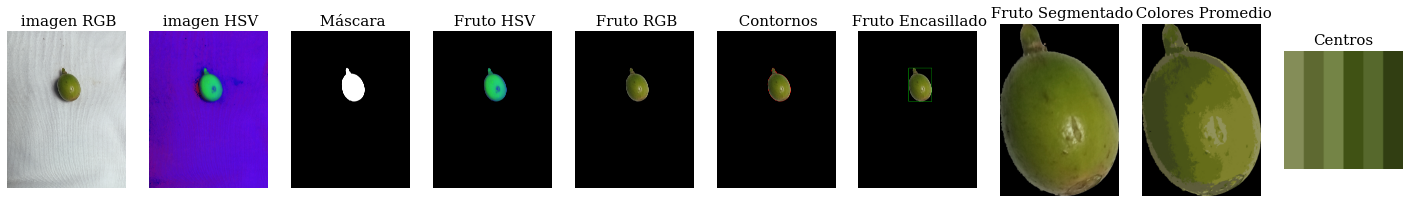

In [ ]:
proc= proceso()
proc.flujo(1,14,0)#flujo(a,b,c) a=[1-5],([0-14]para c=0 ó [0-70]para c=1),[0-1]

In [ ]:
#nuProc= procesNuc()
#nuProc.muestra(e,m)#Escala de color:[1-5],muestra:[0-14]

Se guarda los centros de cada una de las muestras de entrenamiento y validación de cada clase

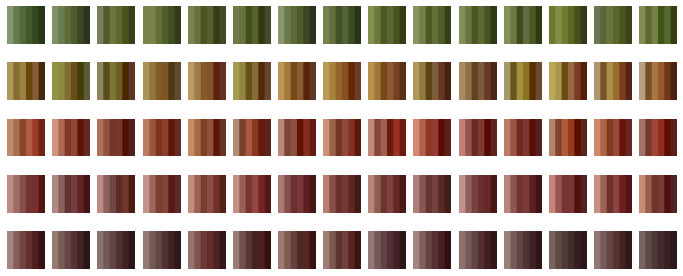

In [ ]:
nuProc= procesNuc()
plt.figure(figsize=(12,5))
nuProc.muestras()

*Figura: centros de las imagenes segmentadas del conjunto de validación*

Concatenando los centros de las muestras de entrenamiento se obtiene una imagen de referencia para cada clase

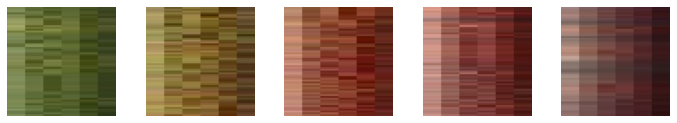

In [ ]:
plt.figure(figsize=(12,2))
nuProc.nucleos()

*Figura: Imagenes construidas con las muestras de entrenamiento de cada clase*

Agregando ruido a la imagen se pueden comparar los histogramas de las muestras de validación con los de la imagen de referencia.

<ipython-input-48-552be25736df>:22: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  plt.subplot(2,2,4),plt.plot(histN,'k',label='Nucleo'),plt.legend(loc=0)


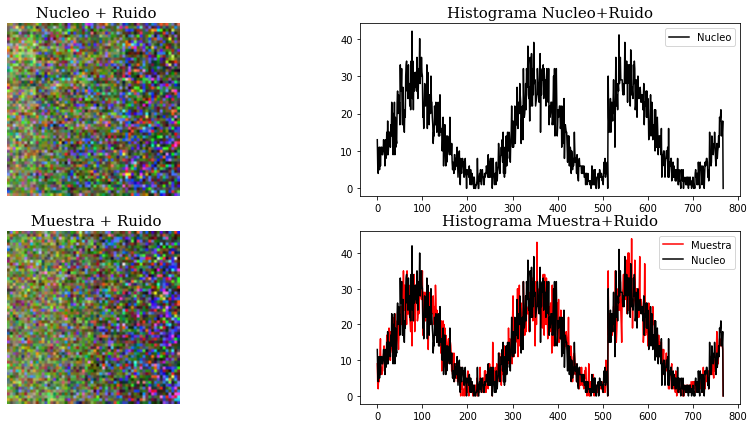

In [ ]:
nuProc= procesNuc()
plt.figure(figsize=(15,7))
nuProc.comparar(1,1,3)# Escala nucleo:[1-5], Escala Muestra: [1-5], muestra: [0-14]

Text(0, 0.5, 'y')

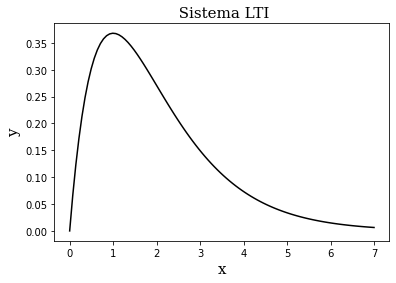

In [ ]:
nuProc.lti()
plt.title(" Sistema LTI",fontdict=font)
plt.xlabel('x',fontdict=font)
plt.ylabel('y',fontdict=font)

In [ ]:
#nuProc.muestra(2,3)#Escala de color:[1-5],muestra:[0-14]

In [ ]:
#nuProc.nucleo(4)#Escala de color

0.9965773794812093

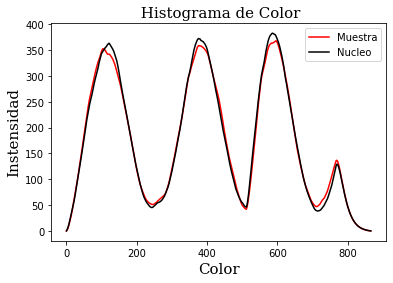

In [ ]:
a=1
b=1
c=14
nuProc= procesNuc()
#plt.figure(figsize=(9,5))
plt.plot(nuProc.nuRuido(a,b,c)[0],'r',label='Muestra')
plt.plot(nuProc.nuRuido(a,b,c)[1],'k',label='Nucleo')#Recibe:escala de nucleo[1-5], escala de la muestra[1-5], muestra[0-14]
    #plt.plot(data,'r',label='Muestra')
    #plt.plot(data1,'k',label='NucleoReferencia')
plt.legend(loc=0)
plt.title(" Histograma de Color",fontdict=font)
plt.xlabel('Color',fontdict=font)
plt.ylabel('Instensidad',fontdict=font)
nuProc.nuRuido(a,b,c)[2]

(<matplotlib.axes._subplots.AxesSubplot at 0x7fd64f402df0>,
 <matplotlib.axes._subplots.AxesSubplot at 0x7fd64f402df0>)

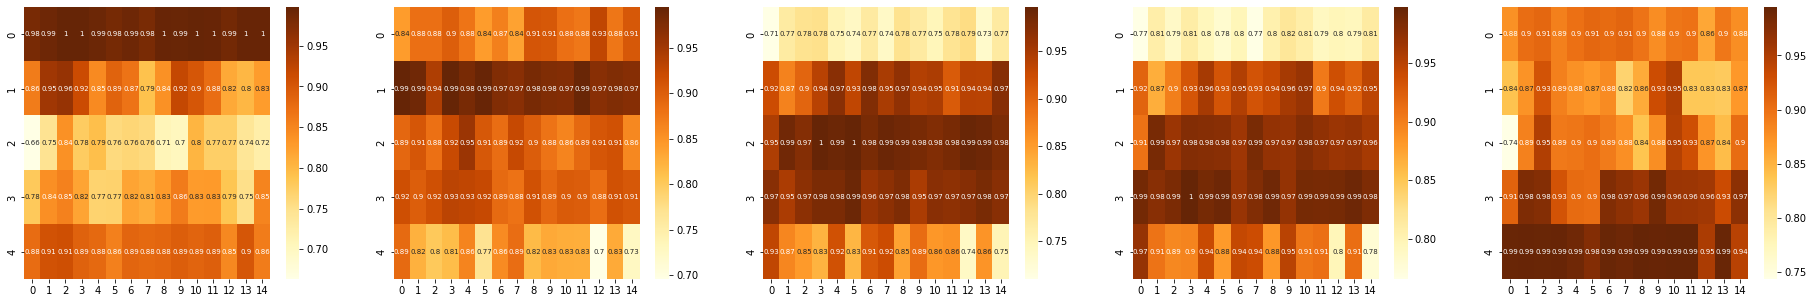

In [ ]:
#plt.figure(figsize=(25,50))
plt.figure(figsize=(32,5))
plt.subplot(1,5,1),nuProc.correlaciones(1)
plt.subplot(1,5,2),nuProc.correlaciones(2)
plt.subplot(1,5,3),nuProc.correlaciones(3)
plt.subplot(1,5,4),nuProc.correlaciones(4)
plt.subplot(1,5,5),nuProc.correlaciones(5)

*Correlación de todas las muestras con cada  referencia*

(<matplotlib.axes._subplots.AxesSubplot at 0x7fd65258a820>,
 <matplotlib.axes._subplots.AxesSubplot at 0x7fd65258a820>)

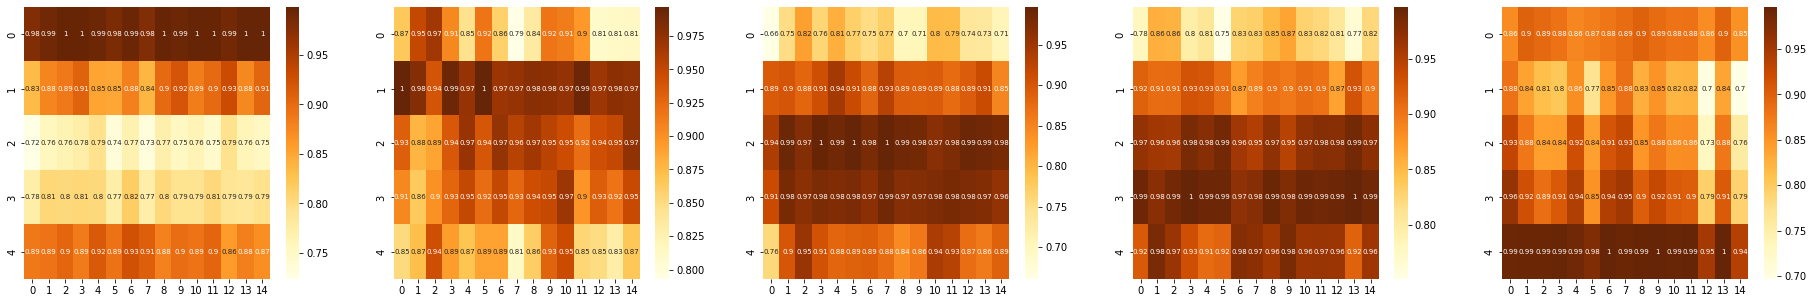

In [ ]:
plt.figure(figsize=(32,5))
plt.subplot(1,5,1),sns.heatmap(nuProc.correlacionesClase(1), annot=True, annot_kws={"size": 7},cmap="YlOrBr")
plt.subplot(1,5,2),sns.heatmap(nuProc.correlacionesClase(2), annot=True, annot_kws={"size": 7},cmap="YlOrBr")
plt.subplot(1,5,3),sns.heatmap(nuProc.correlacionesClase(3), annot=True, annot_kws={"size": 7},cmap="YlOrBr")
plt.subplot(1,5,4),sns.heatmap(nuProc.correlacionesClase(4), annot=True, annot_kws={"size": 7},cmap="YlOrBr")
plt.subplot(1,5,5),sns.heatmap(nuProc.correlacionesClase(5), annot=True, annot_kws={"size": 7},cmap="YlOrBr")

*Correlación de cada muestra con todas las referencias*

Text(105.0, 0.5, 'Escala')

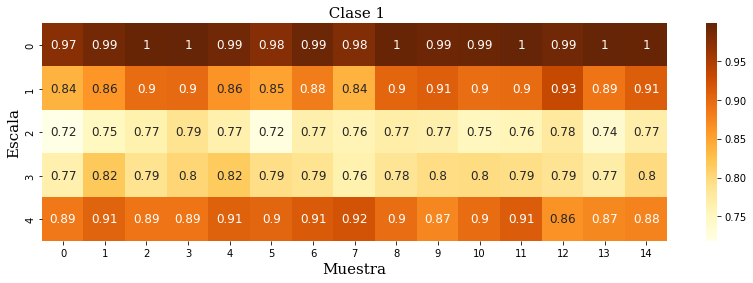

In [ ]:
plt.figure(figsize=(14,4))
nuProc= procesNuc()
clas=nuProc.correlacionesClase(1)#recibe el numero de la escala: [1-5]
sns.heatmap(clas, annot=True, annot_kws={"size": 12},cmap="YlOrBr")
plt.title(" Clase 1",fontdict=font)
plt.xlabel('Muestra',fontdict=font)
plt.ylabel('Escala',fontdict=font)

Text(105.0, 0.5, 'Escala')

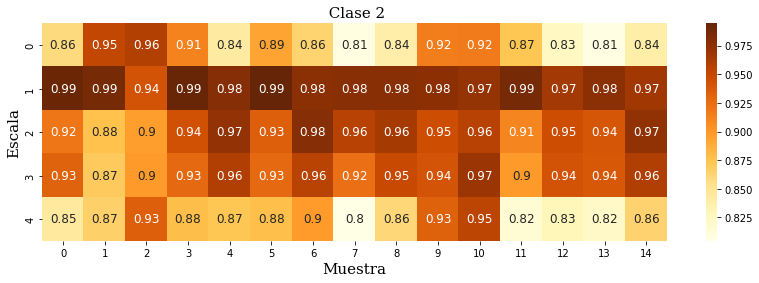

In [ ]:
plt.figure(figsize=(14,4))
nuProc= procesNuc()
clas=nuProc.correlacionesClase(2)#recibe el numero de la escala: [1-5]
sns.heatmap(clas, annot=True, annot_kws={"size": 12},cmap="YlOrBr")
plt.title(" Clase 2",fontdict=font)
plt.xlabel('Muestra',fontdict=font)
plt.ylabel('Escala',fontdict=font)

Text(105.0, 0.5, 'Escala')

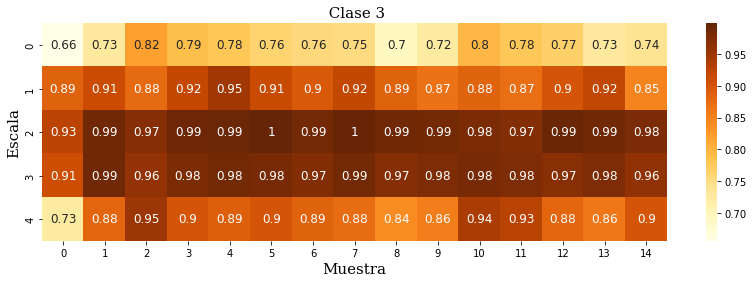

In [ ]:
plt.figure(figsize=(14,4))
nuProc= procesNuc()
clas=nuProc.correlacionesClase(3)#recibe el numero de la escala: [1-5]
sns.heatmap(clas, annot=True, annot_kws={"size": 12},cmap="YlOrBr")
plt.title(" Clase 3",fontdict=font)
plt.xlabel('Muestra',fontdict=font)
plt.ylabel('Escala',fontdict=font)

Text(105.0, 0.5, 'Escala')

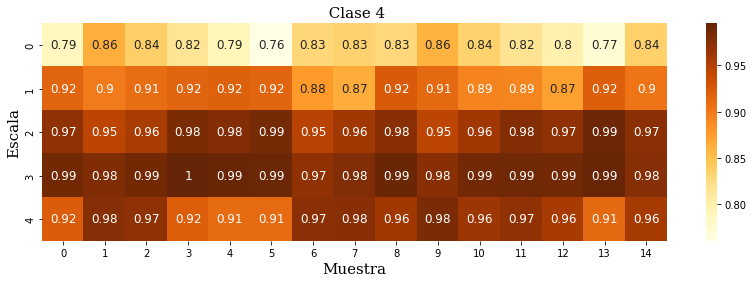

In [ ]:
plt.figure(figsize=(14,4))
nuProc= procesNuc()
clas=nuProc.correlacionesClase(4)#recibe el numero de la escala: [1-5]
sns.heatmap(clas, annot=True, annot_kws={"size": 12},cmap="YlOrBr")
plt.title(" Clase 4",fontdict=font)
plt.xlabel('Muestra',fontdict=font)
plt.ylabel('Escala',fontdict=font)

Text(105.0, 0.5, 'Escala')

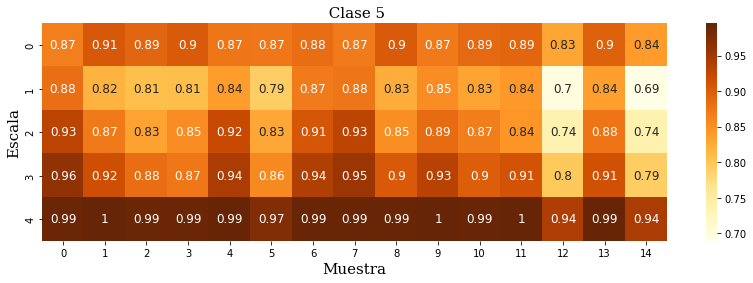

In [ ]:
plt.figure(figsize=(14,4))
nuProc= procesNuc()
clas=nuProc.correlacionesClase(5)#recibe el numero de la escala: [1-5]
sns.heatmap(clas, annot=True, annot_kws={"size": 12},cmap="YlOrBr")
plt.title(" Clase 5",fontdict=font)
plt.xlabel('Muestra',fontdict=font)
plt.ylabel('Escala',fontdict=font)

In [ ]:
nuProc= procesNuc()
max1=np.array([])
A=nuProc.correlacionesClase(1)
for j in range (0,15,1):
  a=A[0:5,j]
  max1=np.append(max1,np.argmax(a))

max1

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [ ]:
nuProc= procesNuc()
max2=np.array([])
A=nuProc.correlacionesClase(2)
for j in range (0,15,1):
  a=A[0:5,j]
  max2=np.append(max2,np.argmax(a))

max2

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 2.])

In [ ]:
nuProc= procesNuc()
max3=np.array([])
A=nuProc.correlacionesClase(3)
for j in range (0,15,1):
  a=A[0:5,j]
  max3=np.append(max3,np.argmax(a))

max3

array([2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 3., 2., 2., 2., 2.])

In [ ]:
nuProc= procesNuc()
max4=np.array([])
A=nuProc.correlacionesClase(4)
for j in range (0,15,1):
  a=A[0:5,j]
  max4=np.append(max4,np.argmax(a))

max4

array([3., 4., 3., 3., 3., 3., 3., 4., 3., 4., 3., 3., 3., 3., 3.])

In [ ]:
nuProc= procesNuc()
max5=np.array([])
A=nuProc.correlacionesClase(5)
for j in range (0,15,1):
  a=A[0:5,j]
  max5=np.append(max5,np.argmax(a))

max5

array([4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4.])

In [ ]:
uno=np.ones(15)*0
dos=np.ones(15)*1
tres=np.ones(15)*2
cua=np.ones(15)*3
cin=np.ones(15)*4

A=np.append(uno,dos)
B=np.append(A,tres)
C=np.append(B,cua)
D=np.append(C,cin)

AA=np.append(max1,max2)
BB=np.append(AA,max3)
CC=np.append(BB,max4)
DD=np.append(CC,max5)

In [ ]:
cm=confusion_matrix(list(D), list(DD))

Text(0.5, 1.0, 'Matriz de confusión')

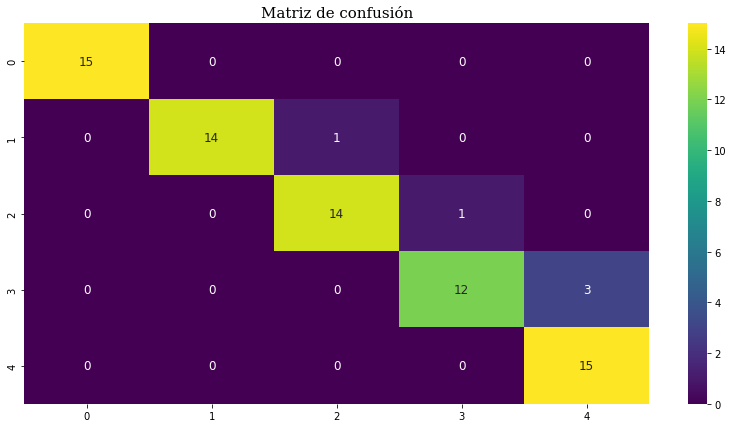

In [ ]:
plt.figure(figsize=(14,7))
nuProc= procesNuc()
sns.heatmap(cm, annot=True, annot_kws={"size": 12},cmap='viridis')
plt.title("Matriz de confusión",fontdict=font)

## Conclusiones

Se extraen características de color usando umbrales detección contornos y segmentación, aplicado a imágenes de cerezas de café con la plataforma Python-OpenCV, el contorno de las imágenes es bueno para intentar comprender el problema y acercarse más a él. Sin embargo, los contornos serán más precisos si se emplean las condiciones de iluminación adecuadas, con esto, también  mejorará la información que brinda cada cereza de café.

##Referentes

[1] Phakade, S. V., D. Flora, H. Malashree and J. Rashmi. 2014. Automatic fruit defect detection using HSV and RGB color sapce model. *Int. J. Innov. Res. Comp. Sci. Technol.* 2(3): 67-73.

[2] Blasco, J., N. Aleixos, S. Cubero, J.Gómez-Sanchís and E. Moltó. 2009. Automatic sorting of satsuma (citrusunshiu) segments using computer vision and morphological features. Comput. *Electron. Agric*. 66(1): 1-8.

[3] Lin, C., C. H. Su, H. S. Huang and K. C. Fan. 2011. Colour image segmentation using relative values of RGB in various illumination circumstances. *Int. J. Com*. 5(2): 252-261.

[4] Rahman, M., & Oliver, M. (2019). Detection and Contouring of BAU-Kul using Image Processing Techniques. *Annals of Bangladesh Agriculture*, 23(2), 15–25

[5] Vision, O. S. (17 de nov de 2022). OpenCV . Obtenido de OpenCV : https://docs.opencv.org/4.x/d4/d73/tutorial_py_contours_begin.html

[6] Vision, O. S. (17 de nov de 2022). OpenCV . Obtenido de OpenCV : https://docs.opencv.org/4.x/dc/da5/tutorial_py_drawing_functions.html

[7] Obtenido de: http://163.10.22.82/OAS/Agrupamiento_Kmedias/definicin.html